<a href="https://colab.research.google.com/github/Leo-Mtz/mineria-de-datos/blob/main/LigaMX_Jornada17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset: 18 partidos

 jornada      equipo_local equipo_visita                ganador
      15          Mazatlán     Querétaro                 Empate
      15 Atlético San Luis         Pumas             Gana Pumas
      15            Necaxa        Tigres                 Empate
      15         Cruz Azul       Tijuana                 Empate
      15         Monterrey       Pachuca           Gana Pachuca
      15            Chivas        Puebla            Gana Chivas
      15              León     FC Juárez              Gana León
      15           América        Toluca           Gana América
      15            Santos         Atlas             Gana Atlas
      16         Querétaro     Cruz Azul                 Empate
      16             Pumas        Juarez             Gana Pumas
      16         Monterrey        Puebla         Gana Monterrey
      16         

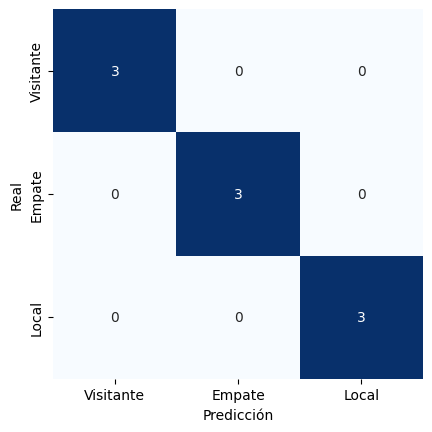

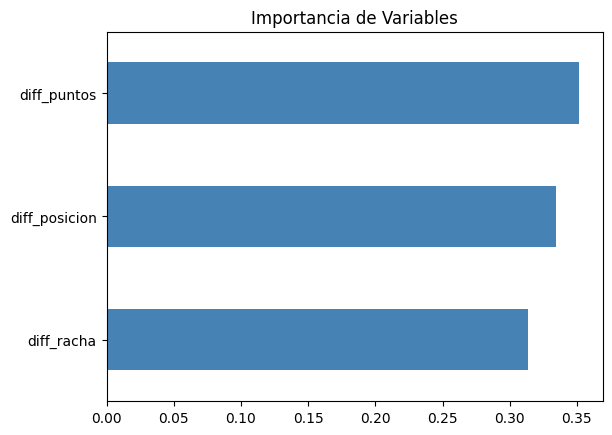


======= PREDICCIONES JORNADA 17 =======

  Puebla vs Querétaro  →  Empate (B)
    Empate (B)             54.8% ██████████
    Gana local (A)         37.8% ███████
    Gana visitante (C)      7.4% █

  Pachuca vs Pumas  →  Empate (B)
    Empate (B)             51.0% ██████████
    Gana local (A)         47.2% █████████
    Gana visitante (C)      1.8% 

  Tigres vs Mazatlán  →  Empate (B)
    Empate (B)             60.4% ████████████
    Gana local (A)         38.0% ███████
    Gana visitante (C)      1.6% 

  Toluca vs León  →  Gana local (A)
    Gana local (A)         51.0% ██████████
    Empate (B)             47.4% █████████
    Gana visitante (C)      1.6% 

  Chivas vs Tijuana  →  Gana local (A)
    Gana local (A)         57.0% ███████████
    Empate (B)             43.0% ████████
    Gana visitante (C)      0.0% 

  América vs Atlas  →  Empate (B)
    Empate (B)             62.6% ████████████
    Gana local (A)         28.6% █████
    Gana visitante (C)      8.8% █

  FC Juárez 

In [ ]:
# -*- coding: utf-8 -*-
"""LigaMX-Jornada17.ipynb

"""
#Leo Martinez 177192
# Predicción de Resultados Liga MX con Random Forest
# Basado en el enfoque de Python Data Science Handbook (05.08)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Montar Google Drive y cargar datos
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/dataset_liga_mx_jornadas_13_14_15_16_base.csv')
df = df.dropna(subset=['equipo_local', 'equipo_visita'])  # eliminar filas vacías
df['equipo_local'] = df['equipo_local'].str.strip()
df['equipo_visita'] = df['equipo_visita'].str.strip()
df['resultado'] = pd.to_numeric(df['resultado'], errors='coerce')
df = df.dropna(subset=['resultado'])
df['resultado'] = df['resultado'].astype(int)

# Auto-calcular diferencias (evita errores manuales en el CSV)
df['diff_puntos'] = df['local_puntos'] - df['visita_puntos']
df['diff_posicion'] = df['visita_posicion'] - df['local_posicion']  # positivo = local mejor posición
if df['local_racha'].notna().any():
    df['diff_racha'] = df['local_racha'] - df['visita_racha']
print(f"Dataset: {df.shape[0]} partidos\n")

# Mostrar partidos con ganador claro
def ganador(row):
    if row['resultado'] == 2: return f"Gana {row['equipo_local']}"
    elif row['resultado'] == 0: return f"Gana {row['equipo_visita']}"
    else: return "Empate"

resumen = df[['jornada', 'equipo_local', 'equipo_visita']].copy()
resumen['ganador'] = df.apply(ganador, axis=1)
print(resumen.to_string(index=False))
print(f"\nDistribución: 0=Gana visita, 1=Empate, 2=Gana local")
print(dict(df['resultado'].value_counts()))

# 2. Preparar features y entrenar (racha es opcional)
all_features = ['diff_puntos', 'diff_racha', 'diff_posicion']
features = [f for f in all_features if df[f].notna().any()]

# Usar solo filas completas para entrenamiento
df_train = df.dropna(subset=features + ['resultado']).copy()
print(f"Features usados: {features}")
print(f"Filas para entrenamiento: {len(df_train)} (de {len(df)} totales)")

X = df_train[features].values
y = df_train['resultado'].values

# Entrenar con todos los datos (pocos partidos, no dividimos)
model = RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42)
model.fit(X, y)

# 3. Verificar ajuste
ypred = model.predict(X)
print(f"\nAccuracy (train): {model.score(X, y):.0%}")
print(classification_report(y, ypred, target_names=['Gana visitante', 'Empate', 'Gana local']))

# 4. Matriz de confusión
mat = confusion_matrix(y, ypred)
sns.heatmap(mat, square=True, annot=True, fmt='d', cbar=False, cmap='Blues',
            xticklabels=['Visitante', 'Empate', 'Local'],
            yticklabels=['Visitante', 'Empate', 'Local'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# 5. Importancia de variables
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='steelblue')
plt.title('Importancia de Variables')
plt.show()

# 6. Extraer stats por equipo (últimos datos disponibles)
local_cols = ['local_puntos', 'local_posicion']
visita_cols = ['visita_puntos', 'visita_posicion']
stat_names = ['puntos', 'posicion']
if 'diff_racha' in features:
    local_cols.insert(1, 'local_racha')
    visita_cols.insert(1, 'visita_racha')
    stat_names.insert(1, 'racha')

local_stats = df.sort_values('jornada').drop_duplicates('equipo_local', keep='last')
local_stats = local_stats.set_index('equipo_local')[local_cols]
local_stats.columns = stat_names

visita_stats = df.sort_values('jornada').drop_duplicates('equipo_visita', keep='last')
visita_stats = visita_stats.set_index('equipo_visita')[visita_cols]
visita_stats.columns = stat_names

team_stats = local_stats.combine_first(visita_stats)

# 7. Predecir Jornada 17
partidos_j17 = [
    ('Puebla', 'Querétaro'),
    ('Pachuca', 'Pumas'),
    ('Tigres', 'Mazatlán'),
    ('Toluca', 'León'),
    ('Chivas', 'Tijuana'),
    ('América', 'Atlas'),
    ('FC Juárez', 'Atlético San Luis'),
    ('Santos', 'Monterrey'),
    ('Cruz Azul', 'Necaxa'),
]

etiquetas = {0: 'Gana visitante (C)', 1: 'Empate (B)', 2: 'Gana local (A)'}

print("\n======= PREDICCIONES JORNADA 17 =======\n")
for local, visita in partidos_j17:
    local_key = [t for t in team_stats.index if local in t]
    visita_key = [t for t in team_stats.index if visita in t]

    if not local_key or not visita_key:
        print(f"  {local} vs {visita}: equipo no encontrado")
        continue

    sl = team_stats.loc[local_key[0]]
    sv = team_stats.loc[visita_key[0]]

    diff = [sl['puntos'] - sv['puntos']]
    if 'diff_racha' in features:
        diff.append(sl['racha'] - sv['racha'])
    diff.append(sv['posicion'] - sl['posicion'])  # positivo = local mejor posición
    x_new = np.array([diff])

    pred = model.predict(x_new)[0]
    probs = model.predict_proba(x_new)[0]

    # Mostrar resultado y confianza
    print(f"  {local} vs {visita}  →  {etiquetas[pred]}")
    for cls, p in sorted(zip(model.classes_, probs), key=lambda x: -x[1]):
        barra = '█' * int(p * 20)
        print(f"    {etiquetas[cls]:22s} {p:5.1%} {barra}")
    print()